# Untuned benchmark


10 datasets and 7 classifiers

In [2]:
from pathlib import Path
import os
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
def find_repo_root(start_path: Path = Path.cwd()) -> Path:
    current = start_path.resolve()
    while current != current.parent:
        if (current / "scripts" / "run_experiment.py").exists():
            return current
        current = current.parent
    raise FileNotFoundError(
        "Could not find repository root containing scripts/run_experiment.py"
    )

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

print("Working directory:", Path.cwd())
assert Path("scripts/run_experiment.py").exists()

Working directory: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow


In [4]:
# Use the same Python executable as the current Jupyter kernel.
# This follows the same approach used in the single-classifier notebooks.

PYTHON_EXECUTABLE = sys.executable

print("Python executable:", PYTHON_EXECUTABLE)

Python executable: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python


In [5]:
# Check that the local package can be imported from the notebook kernel.

import sliding_window_tsc

print("sliding_window_tsc import successful")

sliding_window_tsc import successful


In [6]:
def run_command(command: list[str], continue_on_error: bool = True) -> int:
    command = command.copy()

    if command[0] == "python":
        command[0] = PYTHON_EXECUTABLE
        command.insert(1, "-u")

    print()
    print("=" * 100)
    print("Running command:")
    print(" ".join(command))
    print("=" * 100)
    print()

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    src_path = str((Path.cwd() / "src").resolve())
    existing_pythonpath = env.get("PYTHONPATH", "")

    if existing_pythonpath:
        env["PYTHONPATH"] = src_path + os.pathsep + existing_pythonpath
    else:
        env["PYTHONPATH"] = src_path

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    process.wait()

    if process.returncode != 0 and not continue_on_error:
        raise RuntimeError(f"Command failed with exit code {process.returncode}")

    if process.returncode != 0:
        print(f"WARNING: command failed with exit code {process.returncode}", flush=True)

    return process.returncode

## Benchmark configuration

In [7]:
DATASETS = [
    "GunPoint",
    "ECG200",
    "ItalyPowerDemand",
    "Coffee",
    "Fish",
    "Beef",
    "Plane",
    "TwoLeadECG",
    "Wafer",
    "FaceFour",
]

# Low-cost / low-moderate-cost classifiers kept for the first untuned benchmark.
# WEASEL is kept as a dictionary-based baseline.
# QUANTClassifier uses the correct aeon class name: QUANTClassifier, not QuantClassifier.
CLASSIFIERS = [
    "MiniRocketClassifier",
    "HydraClassifier",
    "QUANTClassifier",
    "WEASEL",
    "TimeSeriesForestClassifier",
    "Catch22Classifier",
    "RDSTClassifier",
    "KNeighborsTimeSeriesClassifier",
]

WINDOW_START = "0.04"
WINDOW_END = "0.50"
WINDOW_STEP = "0.02"

STRIDE_RATIOS = ["0.1", "0.2", "0.5"]

RANDOM_STATE = "42"

BENCHMARK_ROOT = Path("results/benchmark_10_untuned/untuned")
PLOTS_ROOT = Path("plots/benchmark_10_untuned/untuned")

BENCHMARK_ROOT.mkdir(parents=True, exist_ok=True)
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Number of datasets:", len(DATASETS))
print("Number of classifiers:", len(CLASSIFIERS))
print("Total dataset/classifier runs:", len(DATASETS) * len(CLASSIFIERS))
print("Configurations per run:", 50 * len(STRIDE_RATIOS))
print("Total window/stride configurations:", len(DATASETS) * len(CLASSIFIERS) * 50 * len(STRIDE_RATIOS))

Number of datasets: 10
Number of classifiers: 8
Total dataset/classifier runs: 80
Configurations per run: 150
Total window/stride configurations: 12000


In [7]:
# Check which dataset folders are available.

missing_datasets = []
available_datasets = []

for dataset in DATASETS:
    dataset_folder = Path("data/raw") / dataset
    if dataset_folder.exists():
        available_datasets.append(dataset)
    else:
        missing_datasets.append(dataset)

print("Available datasets:", available_datasets)
print("Missing datasets:", missing_datasets)

if missing_datasets:
    print()
    print("WARNING: some datasets are missing.")
    print("Download them from the Time Series Classification archive and place them under data/raw/<DatasetName>.")

Available datasets: ['GunPoint', 'ECG200', 'ItalyPowerDemand', 'Coffee', 'Fish', 'Beef', 'Plane', 'TwoLeadECG', 'Wafer', 'FaceFour']
Missing datasets: []


In [8]:
# Optional classifier import check.
# This cell does not stop the notebook if a classifier is unavailable.

IMPORT_CHECKS = {
    "MiniRocketClassifier": "from aeon.classification.convolution_based import MiniRocketClassifier",
    "HydraClassifier": "from aeon.classification.convolution_based import HydraClassifier",
    "QUANTClassifier": "from aeon.classification.interval_based import QUANTClassifier",
    "WEASEL": "from aeon.classification.dictionary_based import WEASEL",
    "TimeSeriesForestClassifier": "from aeon.classification.interval_based import TimeSeriesForestClassifier",
    "Catch22Classifier": "from aeon.classification.feature_based import Catch22Classifier",
    "RDSTClassifier": "from aeon.classification.shapelet_based import RDSTClassifier",
    "KNeighborsTimeSeriesClassifier": "from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier",
}

available_classifiers = []

for classifier, import_statement in IMPORT_CHECKS.items():
    print()
    print(classifier)
    try:
        exec(import_statement)
        print("  import successful")
        available_classifiers.append(classifier)
    except Exception as exc:
        print("  import failed:", repr(exc))

print()
print("Available classifiers:", available_classifiers)


MiniRocketClassifier
  import successful

HydraClassifier
  import successful

QUANTClassifier
  import successful

WEASEL
  import successful

TimeSeriesForestClassifier
  import successful

Catch22Classifier
  import successful

RDSTClassifier
  import successful

KNeighborsTimeSeriesClassifier
  import successful

Available classifiers: ['MiniRocketClassifier', 'HydraClassifier', 'QUANTClassifier', 'WEASEL', 'TimeSeriesForestClassifier', 'Catch22Classifier', 'RDSTClassifier', 'KNeighborsTimeSeriesClassifier']


In [9]:
# By default, run only classifiers that passed the import check.
# If you want to force the original list, replace CLASSIFIERS_TO_RUN with CLASSIFIERS.

CLASSIFIERS_TO_RUN = available_classifiers

print("Classifiers to run:", CLASSIFIERS_TO_RUN)

Classifiers to run: ['MiniRocketClassifier', 'HydraClassifier', 'QUANTClassifier', 'WEASEL', 'TimeSeriesForestClassifier', 'Catch22Classifier', 'RDSTClassifier', 'KNeighborsTimeSeriesClassifier']


## Run the untuned benchmark

The benchmark is resumable.  
If a CSV already exists for a dataset/classifier pair, the notebook skips that pair.

In [10]:
RUN_BENCHMARK = True

if RUN_BENCHMARK:
    run_log = []

    for dataset in DATASETS:
        dataset_folder = Path("data/raw") / dataset

        if not dataset_folder.exists():
            print(f"Skipping missing dataset: {dataset}")
            run_log.append({
                "dataset": dataset,
                "classifier": None,
                "status": "missing_dataset",
                "return_code": None,
            })
            continue

        for classifier in CLASSIFIERS_TO_RUN:
            output_dir = BENCHMARK_ROOT / dataset / classifier
            output_dir.mkdir(parents=True, exist_ok=True)

            existing_csv_files = sorted(output_dir.glob("*.csv"))

            if existing_csv_files:
                print()
                print(f"Skipping existing result: dataset={dataset}, classifier={classifier}")
                print(f"Existing file: {existing_csv_files[-1]}")
                run_log.append({
                    "dataset": dataset,
                    "classifier": classifier,
                    "status": "already_done",
                    "return_code": 0,
                })
                continue

            command = [
                "python", "scripts/run_experiment.py",
                "--dataset-folder", str(dataset_folder),
                "--classifier", classifier,
                "--window-sizes", WINDOW_START, WINDOW_END, WINDOW_STEP,
                "--percentages",
                "--stride-ratios", *STRIDE_RATIOS,
                "--output-dir", str(output_dir),
                "--random-state", RANDOM_STATE,
            ]

            return_code = run_command(command, continue_on_error=True)

            run_log.append({
                "dataset": dataset,
                "classifier": classifier,
                "status": "executed" if return_code == 0 else "failed_command",
                "return_code": return_code,
            })

    run_log_df = pd.DataFrame(run_log)
    display(run_log_df)
    run_log_df.to_csv(BENCHMARK_ROOT / "run_log.csv", index=False)
else:
    print("RUN_BENCHMARK is False. No experiments were launched.")


Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_experiment.py --dataset-folder data/raw/GunPoint --classifier MiniRocketClassifier --window-sizes 0.04 0.50 0.02 --percentages --stride-ratios 0.1 0.2 0.5 --output-dir results/benchmark_10datasets_lowcost_weasel_quant/untuned/GunPoint/MiniRocketClassifier --random-state 42


GunPoint / MiniRocketClassifier: 100%|██████████| 72/72 [04:24<00:00,  3.68s/config, status=ok, stride=37, stride_ratio=0.5, window_size=75]

Results saved to: results/benchmark_10datasets_lowcost_weasel_quant/untuned/GunPoint/MiniRocketClassifier/GunPoint_MiniRocketClassifier_20260711_211140.csv

Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_experiment.py --dataset-folder data/raw/GunPoint --classifier HydraClassifier --window-sizes 0.04 0.50 0.02 --percentages --stride-ratios 0.1 0.2 0.5 --output-dir results/benchmark_10datasets_lowcost_weasel_quant/untuned/Gun

Python(68294) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Fish / HydraClassifier: 100%|██████████| 72/72 [00:03<00:00, 18.07config/s, status=failed, stride=115, stride_ratio=0.5, window_size=231]

Results saved to: results/benchmark_10datasets_lowcost_weasel_quant/untuned/Fish/HydraClassifier/Fish_HydraClassifier_20260712_004608.csv

Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_experiment.py --dataset-folder data/raw/Fish --classifier QUANTClassifier --window-sizes 0.04 0.50 0.02 --percentages --stride-ratios 0.1 0.2 0.5 --output-dir results/benchmark_10datasets_lowcost_weasel_quant/untuned/Fish/QUANTClassifier --random-state 42



Python(68309) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Fish / QUANTClassifier: 100%|██████████| 72/72 [00:02<00:00, 24.36config/s, status=failed, stride=115, stride_ratio=0.5, window_size=231]

Results saved to: results/benchmark_10datasets_lowcost_weasel_quant/untuned/Fish/QUANTClassifier/Fish_QUANTClassifier_20260712_004612.csv

Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_experiment.py --dataset-folder data/raw/Fish --classifier WEASEL --window-sizes 0.04 0.50 0.02 --percentages --stride-ratios 0.1 0.2 0.5 --output-dir results/benchmark_10datasets_lowcost_weasel_quant/untuned/Fish/WEASEL --random-state 42



...

Python(64009) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



FaceFour / RDSTClassifier:   3%|▎         | 2/72 [01:48<56:07, 48.10s/config, status=ok, stride=2, stride_ratio=0.2, window_size=14]  /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/lib/python3.12/site-packages/aeon/transformations/collection/base.py:267: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  return self._transform(X, y)
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/lib/python3.12/site-packages/aeon/transformations/collection/base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)

FaceFour / RDSTClassifier:   6%|▌         | 4/72 [02:16<29:56, 26.41s/config, status=ok, stride=2, stride_ratio=0.1, window_size=21]/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/lib/python3.12/site-packages/aeon/transformations/collection/base.py:267: UserWarning: Some invalid values (inf or nan) where converted f

Python(65035) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



FaceFour / KNeighborsTimeSeriesClassifier: 100%|██████████| 72/72 [19:33<00:00, 16.30s/config, status=ok, stride=87, stride_ratio=0.5, window_size=175]

Results saved to: results/benchmark_10datasets_lowcost_weasel_quant/untuned/FaceFour/KNeighborsTimeSeriesClassifier/FaceFour_KNeighborsTimeSeriesClassifier_20260713_125125.csv


,dataset,classifier,status,return_code
0,GunPoint,MiniRocketClassifier,executed,0
1,GunPoint,HydraClassifier,executed,0
2,GunPoint,QUANTClassifier,executed,0
3,GunPoint,WEASEL,executed,0
4,GunPoint,TimeSeriesForestClassifier,executed,0
...,...,...,...,...
75,FaceFour,WEASEL,executed,0
76,FaceFour,TimeSeriesForestClassifier,executed,0
77,FaceFour,Catch22Classifier,executed,0
78,FaceFour,RDSTClassifier,executed,0


## Load and combine all benchmark results

In [15]:
BENCHMARK_ROOT = Path(
    "results/benchmark10_untuned/untuned"
)

print(BENCHMARK_ROOT.resolve())
print(BENCHMARK_ROOT.exists())

/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned
True


In [16]:
def load_all_results(root: Path) -> pd.DataFrame:
    rows = []

    root = Path(root).resolve()

    excluded_files = {
        "best_empirical_window_region_table.csv",
        "classifier_stride_summary.csv",
        "combined_untuned_results.csv",
        "coverage_summary.csv",
        "global_stride_summary.csv",
        "good_enough_region_summary.csv",
        "run_log.csv",
        "time_summary_by_classifier.csv",
    }

    print("Searching in:", root)
    print("Root exists:", root.exists())

    csv_files = [
        csv_file
        for csv_file in root.rglob("*.csv")
        if csv_file.name not in excluded_files
    ]

    csv_files = sorted(csv_files)

    print("Experiment CSV files found:", len(csv_files))

    for csv_file in csv_files:
        print("Reading:", csv_file)

        try:
            df = pd.read_csv(csv_file)
        except Exception as exc:
            print("Could not read:", csv_file, repr(exc))
            continue

        # Skip files that do not look like experiment results
        required_columns = {
            "dataset",
            "classifier",
            "window_percentage",
            "stride_ratio",
            "series_macro_f1",
        }

        if not required_columns.issubset(df.columns):
            print("Skipped summary/non-result CSV:", csv_file)
            continue

        df["source_file"] = str(csv_file)
        rows.append(df)

    if not rows:
        raise FileNotFoundError(
            f"No valid experiment CSV files found under {root}"
        )

    return pd.concat(rows, ignore_index=True)


results = load_all_results(BENCHMARK_ROOT)

print("Combined shape:", results.shape)
display(results.head())

Searching in: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned
Root exists: True
Experiment CSV files found: 73
Reading: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned/Beef/Catch22Classifier/Beef_Catch22Classifier_20260712_121425.csv
Reading: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned/Beef/HydraClassifier/Beef_HydraClassifier_20260712_115351.csv
Reading: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned/Beef/KNeighborsTimeSeriesClassifier/Beef_KNeighborsTimeSeriesClassifier_20260712_124113.csv
Reading: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned/Beef/MiniRocketClassifier/Beef_MiniRocketClassifier_20260712_115345.csv
Reading: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/results/benchmark10_untuned/untuned/Beef/QUANTClassifier/Beef_QUANTClassifier_20260712_115356.csv
Reading: /Users/

,dataset,classifier,classifier_hyperparameters,window_size,window_percentage,stride,stride_ratio,n_train_windows,n_test_windows,window_accuracy,...,series_accuracy,series_balanced_accuracy,series_macro_f1,fit_time_sec,predict_time_sec,total_time_sec,random_state,status,error,source_file
0,Beef,Catch22Classifier,{},18,0.038298,1,0.1,13590.0,13590.0,0.451361,...,0.633333,0.633333,0.629524,6.259672,1.326160,9.617272,42,ok,NaN,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
1,Beef,Catch22Classifier,{},18,0.038298,3,0.2,4530.0,4530.0,0.473289,...,0.633333,0.633333,0.631933,1.945851,0.450612,2.417987,42,ok,NaN,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
2,Beef,Catch22Classifier,{},18,0.038298,9,0.5,1530.0,1530.0,0.492157,...,0.633333,0.633333,0.643288,0.631371,0.151078,0.800417,42,ok,NaN,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
3,Beef,Catch22Classifier,{},28,0.059574,2,0.1,6660.0,6660.0,0.481982,...,0.666667,0.666667,0.680952,3.015764,0.676726,3.716463,42,ok,NaN,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
4,Beef,Catch22Classifier,{},28,0.059574,5,0.2,2670.0,2670.0,0.508614,...,0.766667,0.766667,0.771282,1.157455,0.276659,1.453418,42,ok,NaN,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...


In [17]:
# Basic cleanup and type normalization.

numeric_columns = [
    "window_size",
    "window_percentage",
    "stride",
    "stride_ratio",
    "series_macro_f1",
    "series_accuracy",
    "series_balanced_accuracy",
    "fit_time_sec",
    "predict_time_sec",
    "total_time_sec",
    "n_train_windows",
    "n_test_windows",
]

for column in numeric_columns:
    if column in results.columns:
        results[column] = pd.to_numeric(results[column], errors="coerce")

if "status" in results.columns:
    ok_results = results[results["status"] == "ok"].copy()
else:
    ok_results = results.copy()
    ok_results["status"] = "ok"

print("All rows:", len(results))
print("OK rows:", len(ok_results))

if "status" in results.columns:
    display(results["status"].value_counts(dropna=False))

combined_file = BENCHMARK_ROOT / "combined_untuned_results.csv"
results.to_csv(combined_file, index=False)
print("Saved combined results to:", combined_file)

All rows: 4968
OK rows: 3498


status
ok        3498
failed    1470
Name: count, dtype: int64

Saved combined results to: results/benchmark10_untuned/untuned/combined_untuned_results.csv


In [13]:
# Summary of successful configurations by dataset/classifier.

coverage = (
    results
    .groupby(["dataset", "classifier", "status"], dropna=False)
    .size()
    .reset_index(name="n_rows")
    .sort_values(["dataset", "classifier", "status"])
)

display(coverage)

coverage_file = BENCHMARK_ROOT / "coverage_summary.csv"
coverage.to_csv(coverage_file, index=False)
print("Saved coverage summary to:", coverage_file)

,dataset,classifier,status,n_rows
0,Beef,Catch22Classifier,ok,72
1,Beef,HydraClassifier,failed,72
2,Beef,KNeighborsTimeSeriesClassifier,ok,72
3,Beef,MiniRocketClassifier,ok,72
4,Beef,QUANTClassifier,failed,72
...,...,...,...,...
80,TwoLeadECG,WEASEL,ok,63
81,Wafer,Catch22Classifier,ok,72
82,Wafer,HydraClassifier,failed,72
83,Wafer,QUANTClassifier,failed,72


Saved coverage summary to: results/benchmark_10datasets_lowcost_weasel_quant/untuned/coverage_summary.csv


## Plot 1: general Macro F1 trend by stride ratio

This plot averages Macro F1 across all available datasets and classifiers.

In [14]:
global_stride_summary = (
    ok_results
    .groupby(["window_percentage", "stride_ratio"], as_index=False)
    .agg(
        mean_macro_f1=("series_macro_f1", "mean"),
        median_macro_f1=("series_macro_f1", "median"),
        std_macro_f1=("series_macro_f1", "std"),
        n_configs=("series_macro_f1", "count"),
    )
    .sort_values(["stride_ratio", "window_percentage"])
)

summary_file = BENCHMARK_ROOT / "global_stride_summary.csv"
global_stride_summary.to_csv(summary_file, index=False)
print("Saved:", summary_file)

display(global_stride_summary.head())

Saved: results/benchmark_10datasets_lowcost_weasel_quant/untuned/global_stride_summary.csv


,window_percentage,stride_ratio,mean_macro_f1,median_macro_f1,std_macro_f1,n_configs
0,0.031250,0.1,0.397599,0.390244,0.014711,4
3,0.034722,0.1,0.962038,0.984543,0.055891,4
6,0.036585,0.1,0.867710,0.905032,0.120218,3
9,0.038298,0.1,0.676597,0.679564,0.126843,6
12,0.038462,0.1,0.845051,0.908206,0.168940,6


Datasets to plot: ['GunPoint', 'ECG200', 'ItalyPowerDemand', 'Coffee', 'Fish', 'Beef', 'Plane', 'TwoLeadECG', 'Wafer', 'FaceFour']
Classifiers to plot: ['MiniRocketClassifier', 'WEASEL', 'TimeSeriesForestClassifier', 'Catch22Classifier', 'RDSTClassifier', 'KNeighborsTimeSeriesClassifier']
Saved: plots/benchmark_10datasets_lowcost_weasel_quant/untuned/macro_f1_grid/macro_f1_grid_classifiers_by_datasets.png


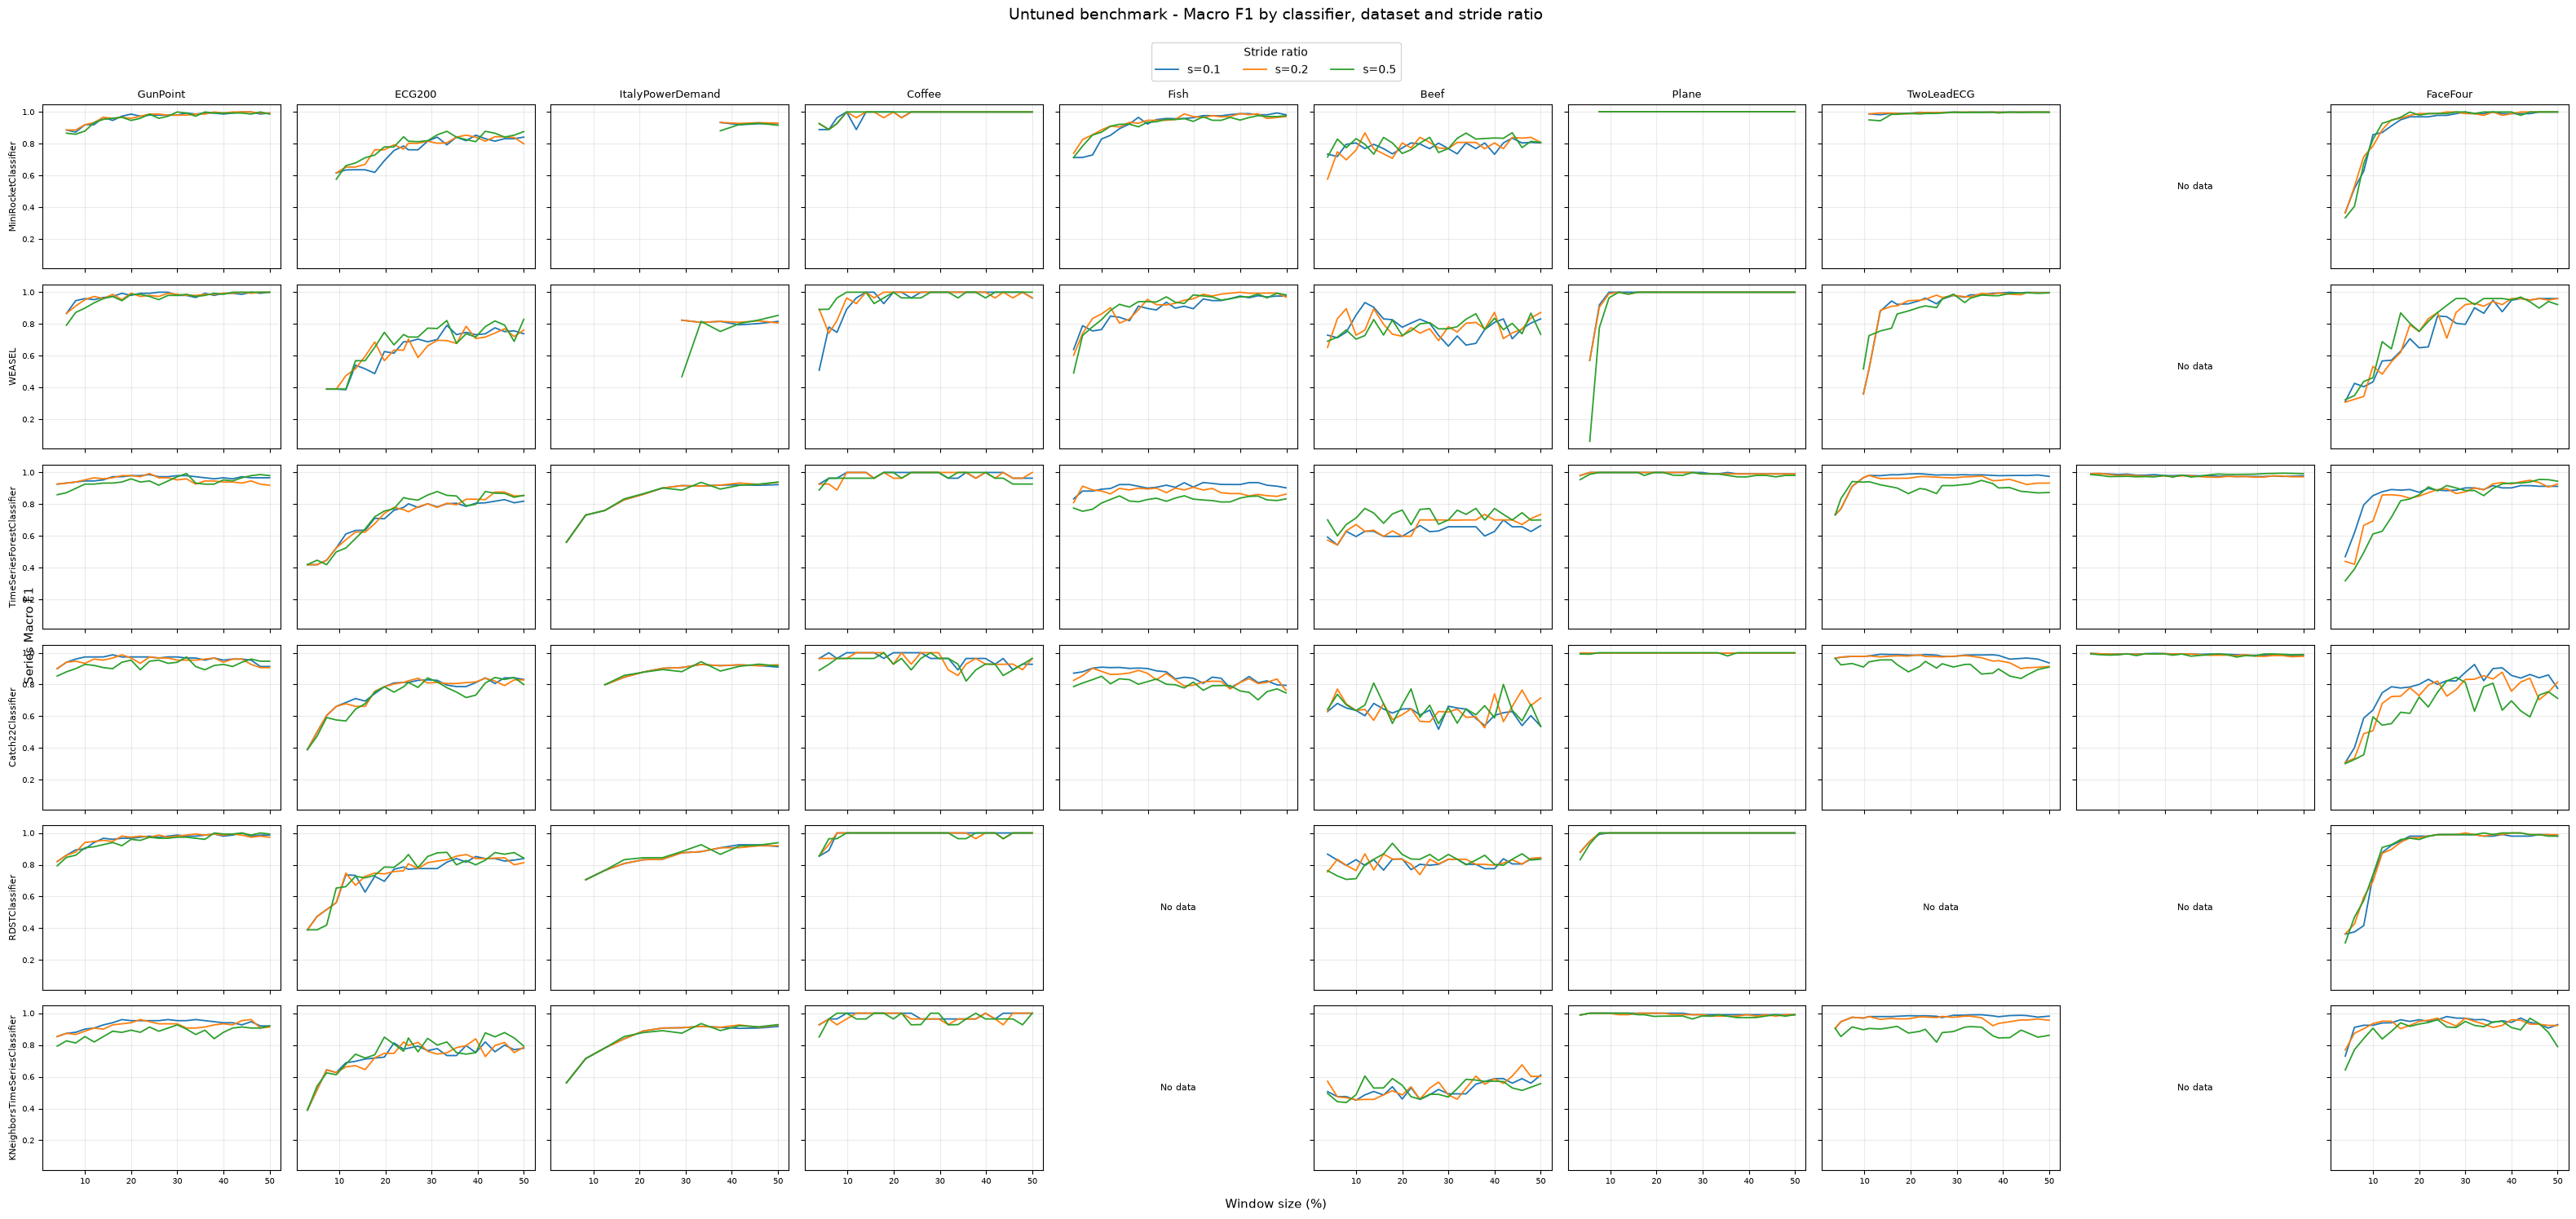

In [26]:
# ---------------------------------------------------------------------
# Grid plot: rows = classifiers, columns = datasets
# Each subplot shows Macro F1 vs window size for the three stride ratios
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

GRID_PLOTS_DIR = PLOTS_ROOT / "macro_f1_grid"
GRID_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plot_df = ok_results.copy()

plot_df["window_percentage_100"] = plot_df["window_percentage"] * 100

# Keep only datasets and classifiers that are actually present in the results
datasets_to_plot = [d for d in DATASETS if d in plot_df["dataset"].unique()]
classifiers_to_plot = [c for c in CLASSIFIERS_TO_RUN if c in plot_df["classifier"].unique()]

print("Datasets to plot:", datasets_to_plot)
print("Classifiers to plot:", classifiers_to_plot)

# In case there are duplicated runs, average only exact duplicates:
# same dataset, classifier, stride ratio, and window size.
# This does NOT average across models or datasets.
grid_df = (
    plot_df
    .groupby(
        ["dataset", "classifier", "stride_ratio", "window_percentage_100"],
        as_index=False,
    )
    .agg(
        series_macro_f1=("series_macro_f1", "mean"),
        n_rows=("series_macro_f1", "count"),
    )
    .sort_values(
        ["classifier", "dataset", "stride_ratio", "window_percentage_100"]
    )
)

n_rows = len(classifiers_to_plot)
n_cols = len(datasets_to_plot)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 2.4 * n_rows),
    sharex=True,
    sharey=True,
)

# Make axes always 2D
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

for row_idx, classifier in enumerate(classifiers_to_plot):
    for col_idx, dataset in enumerate(datasets_to_plot):
        ax = axes[row_idx, col_idx]

        subset = grid_df[
            (grid_df["classifier"] == classifier)
            & (grid_df["dataset"] == dataset)
        ]

        if subset.empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=8,
            )
            ax.set_axis_off()
            continue

        for stride_ratio, group in subset.groupby("stride_ratio"):
            group = group.sort_values("window_percentage_100")

            ax.plot(
                group["window_percentage_100"],
                group["series_macro_f1"],
                linewidth=1.3,
                label=f"s={stride_ratio}",
            )

        if row_idx == 0:
            ax.set_title(dataset, fontsize=9)

        if col_idx == 0:
            ax.set_ylabel(classifier, fontsize=8)

        ax.grid(True, alpha=0.25)
        ax.tick_params(axis="both", labelsize=7)

# Common labels
fig.supxlabel("Window size (%)", fontsize=11)
fig.supylabel("Series Macro F1", fontsize=11)

# One shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Stride ratio",
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "Untuned benchmark - Macro F1 by classifier, dataset and stride ratio",
    fontsize=14,
    y=1.035,
)

fig.tight_layout()

output_file = GRID_PLOTS_DIR / "macro_f1_grid_classifiers_by_datasets.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")

print("Saved:", output_file)
plt.show()

In [22]:
# ---------------------------------------------------------------------
# Compute Top-1, Top-3 and Top-5 window counts
# ---------------------------------------------------------------------

import pandas as pd

plot_df = ok_results.copy()

plot_df["window_percentage_100"] = (
    plot_df["window_percentage"] * 100
).round(0).astype(int)

# Average only exact duplicate configurations
config_df = (
    plot_df
    .groupby(
        [
            "dataset",
            "classifier",
            "stride_ratio",
            "window_percentage_100",
        ],
        as_index=False,
    )
    .agg(
        series_macro_f1=("series_macro_f1", "mean"),
    )
)

ranking_keys = [
    "dataset",
    "classifier",
    "stride_ratio",
]


def get_top_k_counts(
    df: pd.DataFrame,
    k: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    top_rows = []

    for _, group in df.groupby(ranking_keys):

        group = group.sort_values(
            [
                "series_macro_f1",
                "window_percentage_100",
            ],
            ascending=[
                False,
                True,
            ],
        )

        selected = group.head(k).copy()
        selected["top_k"] = k
        top_rows.append(selected)

    if not top_rows:
        raise ValueError("No valid result groups were found.")

    top_k_df = pd.concat(
        top_rows,
        ignore_index=True,
    )

    counts = (
        top_k_df
        .groupby(
            "window_percentage_100",
            as_index=False,
        )
        .agg(
            count=("window_percentage_100", "size"),
            mean_macro_f1=("series_macro_f1", "mean"),
        )
        .sort_values(
            [
                "count",
                "mean_macro_f1",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    counts["window_label"] = (
        counts["window_percentage_100"]
        .astype(str)
        + "%"
    )

    return counts, top_k_df


top1_counts, top1_rows = get_top_k_counts(
    config_df,
    k=1,
)

top3_counts, top3_rows = get_top_k_counts(
    config_df,
    k=3,
)

top5_counts, top5_rows = get_top_k_counts(
    config_df,
    k=5,
)
top10_counts, top10_rows = get_top_k_counts(config_df, k=10)
top20_counts, top20_rows = get_top_k_counts(config_df, k=20)

print("Top-1 counts created:", len(top1_counts))
print("Top-3 counts created:", len(top3_counts))
print("Top-5 counts created:", len(top5_counts))

display(top1_counts.head(10))
display(top3_counts.head(10))
display(top5_counts.head(10))

Top-1 counts created: 34
Top-3 counts created: 39
Top-5 counts created: 42


,window_percentage_100,count,mean_macro_f1,window_label
0,8,12,0.983231,8%
1,10,12,0.980069,10%
2,6,11,0.941220,6%
3,44,11,0.936291,44%
4,38,10,0.897632,38%
5,12,9,0.894492,12%
6,33,8,0.899523,33%
7,42,8,0.892982,42%
8,18,7,0.982497,18%
9,46,7,0.878128,46%


,window_percentage_100,count,mean_macro_f1,window_label
0,46,34,0.901607,46%
1,50,34,0.889989,50%
2,42,32,0.901381,42%
3,10,31,0.982991,10%
4,44,31,0.907802,44%
5,12,30,0.964118,12%
6,48,22,0.919471,48%
7,8,21,0.989378,8%
8,14,21,0.947013,14%
9,38,21,0.915138,38%


,window_percentage_100,count,mean_macro_f1,window_label
0,50,53,0.894323,50%
1,46,53,0.890140,46%
2,42,49,0.901863,42%
3,44,46,0.911618,44%
4,38,44,0.905549,38%
5,12,40,0.971430,12%
6,16,39,0.957429,16%
7,14,37,0.964555,14%
8,10,36,0.982770,10%
9,48,34,0.900083,48%


Saved: plots/benchmark_10_untuned/untuned/top_window_values/top_window_values_top1_top3_top5_top10_top20.png


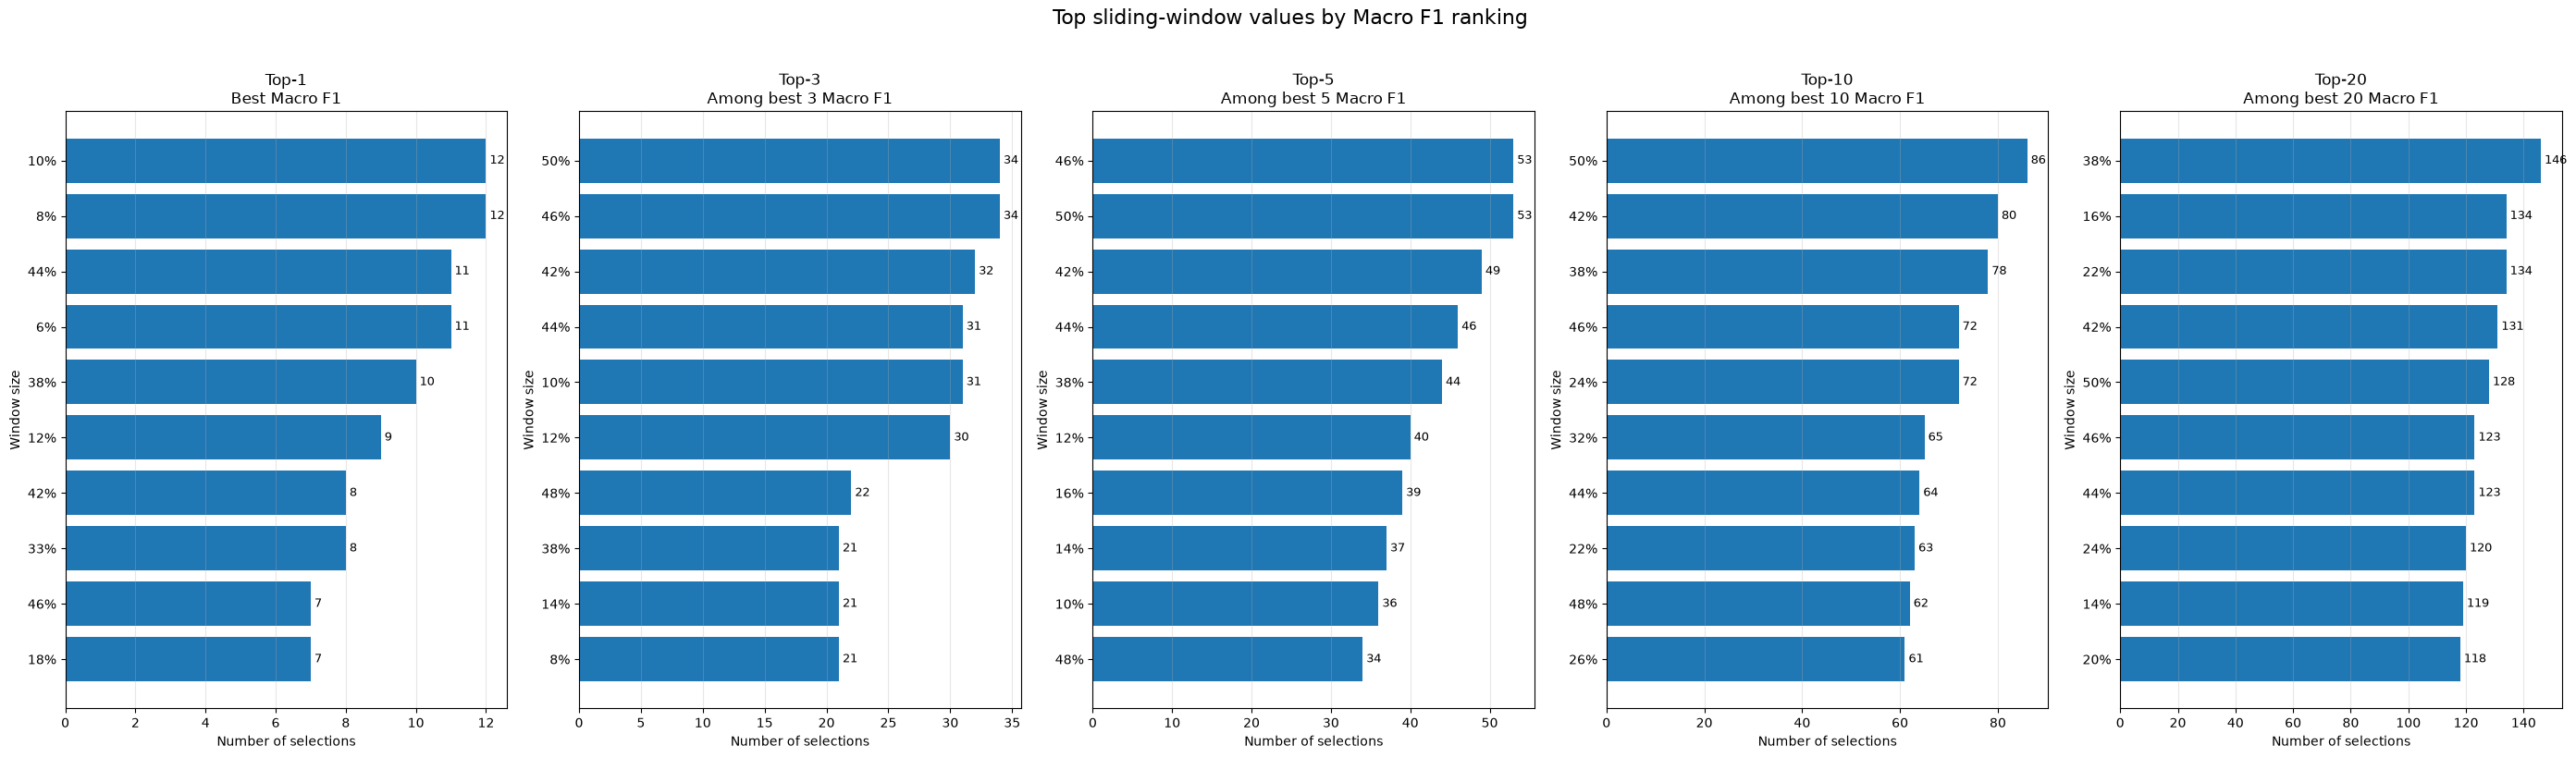

In [23]:
# ---------------------------------------------------------------------
# Single white page with Top-1, Top-3, Top-5, Top-10 and Top-20
# ---------------------------------------------------------------------

TOP_WINDOW_DIR = PLOTS_ROOT / "top_window_values"
TOP_WINDOW_DIR.mkdir(parents=True, exist_ok=True)

plot_specs = [
    {
        "counts": top1_counts,
        "title": "Top-1",
        "subtitle": "Best Macro F1",
    },
    {
        "counts": top3_counts,
        "title": "Top-3",
        "subtitle": "Among best 3 Macro F1",
    },
    {
        "counts": top5_counts,
        "title": "Top-5",
        "subtitle": "Among best 5 Macro F1",
    },
    {
        "counts": top10_counts,
        "title": "Top-10",
        "subtitle": "Among best 10 Macro F1",
    },
    {
        "counts": top20_counts,
        "title": "Top-20",
        "subtitle": "Among best 20 Macro F1",
    },
]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(28, 8),
    facecolor="white",
)

for ax, spec in zip(axes, plot_specs):

    counts_df = (
        spec["counts"]
        .head(10)
        .copy()
        .sort_values("count", ascending=True)
    )

    ax.barh(
        counts_df["window_label"],
        counts_df["count"],
    )

    ax.set_title(
        f'{spec["title"]}\n{spec["subtitle"]}',
        fontsize=12,
    )

    ax.set_xlabel("Number of selections")
    ax.set_ylabel("Window size")
    ax.grid(axis="x", alpha=0.3)

    for i, value in enumerate(counts_df["count"]):
        ax.text(
            value,
            i,
            f" {value}",
            va="center",
            fontsize=9,
        )

fig.suptitle(
    "Top sliding-window values by Macro F1 ranking",
    fontsize=16,
    y=1.02,
)

fig.tight_layout()

output_file = (
    TOP_WINDOW_DIR
    / "top_window_values_top1_top3_top5_top10_top20.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

print("Saved:", output_file)
plt.show()

Saved: plots/benchmark_10_untuned/untuned/top_window_values/top10_window_values_top1_top3_top5.png


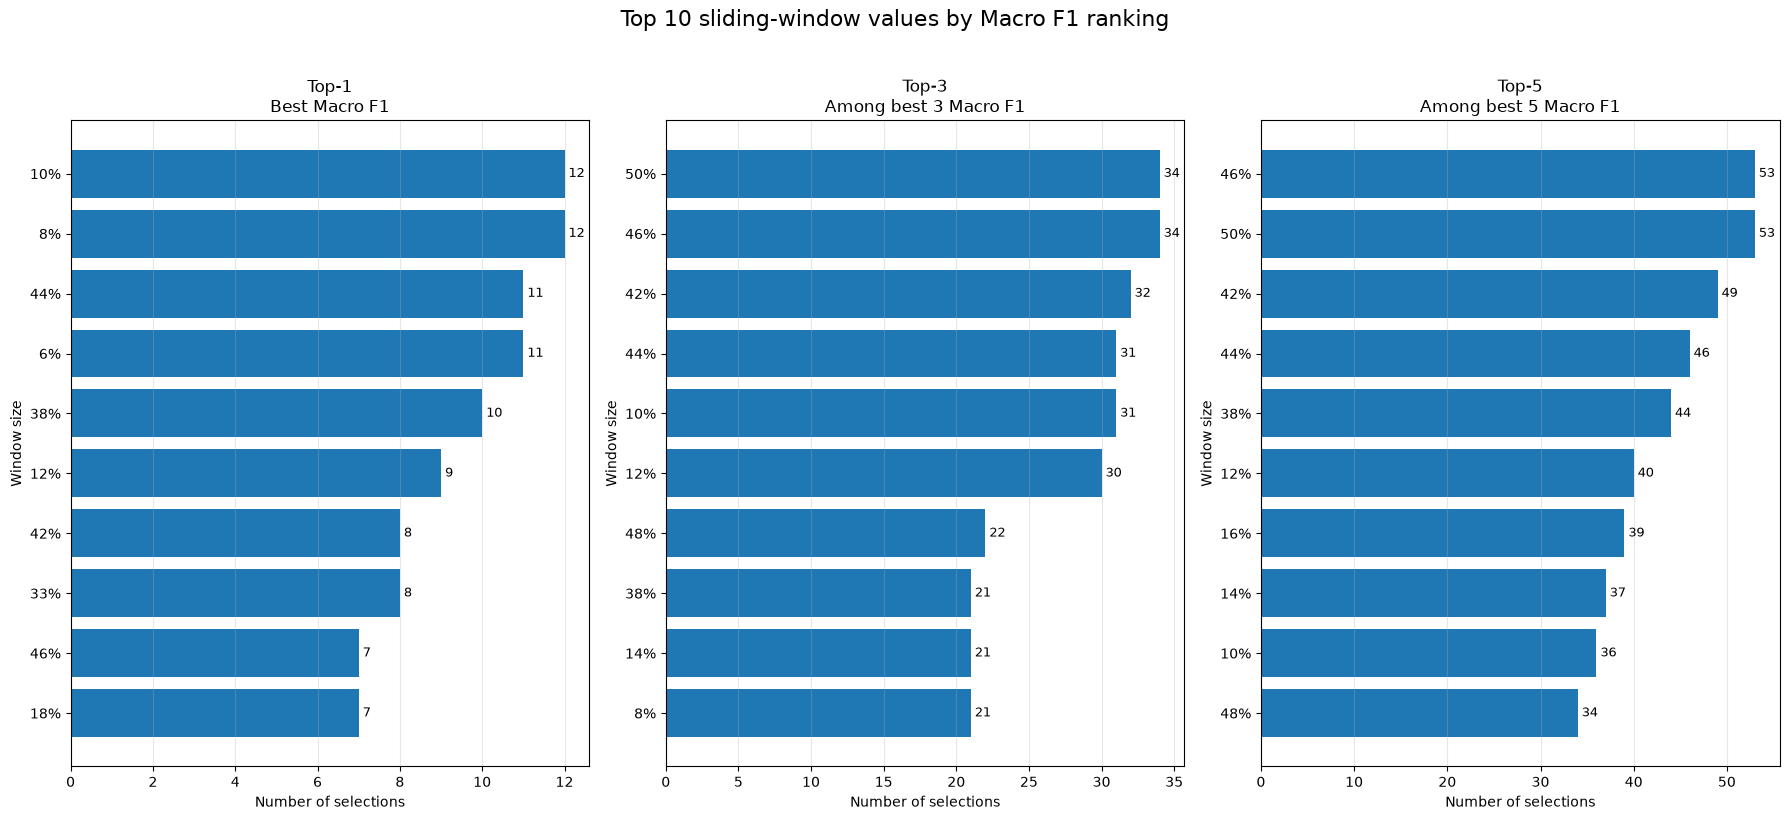

Saved: plots/benchmark_10_untuned/untuned/top_window_values/top20_window_values_top1_top3_top5.png


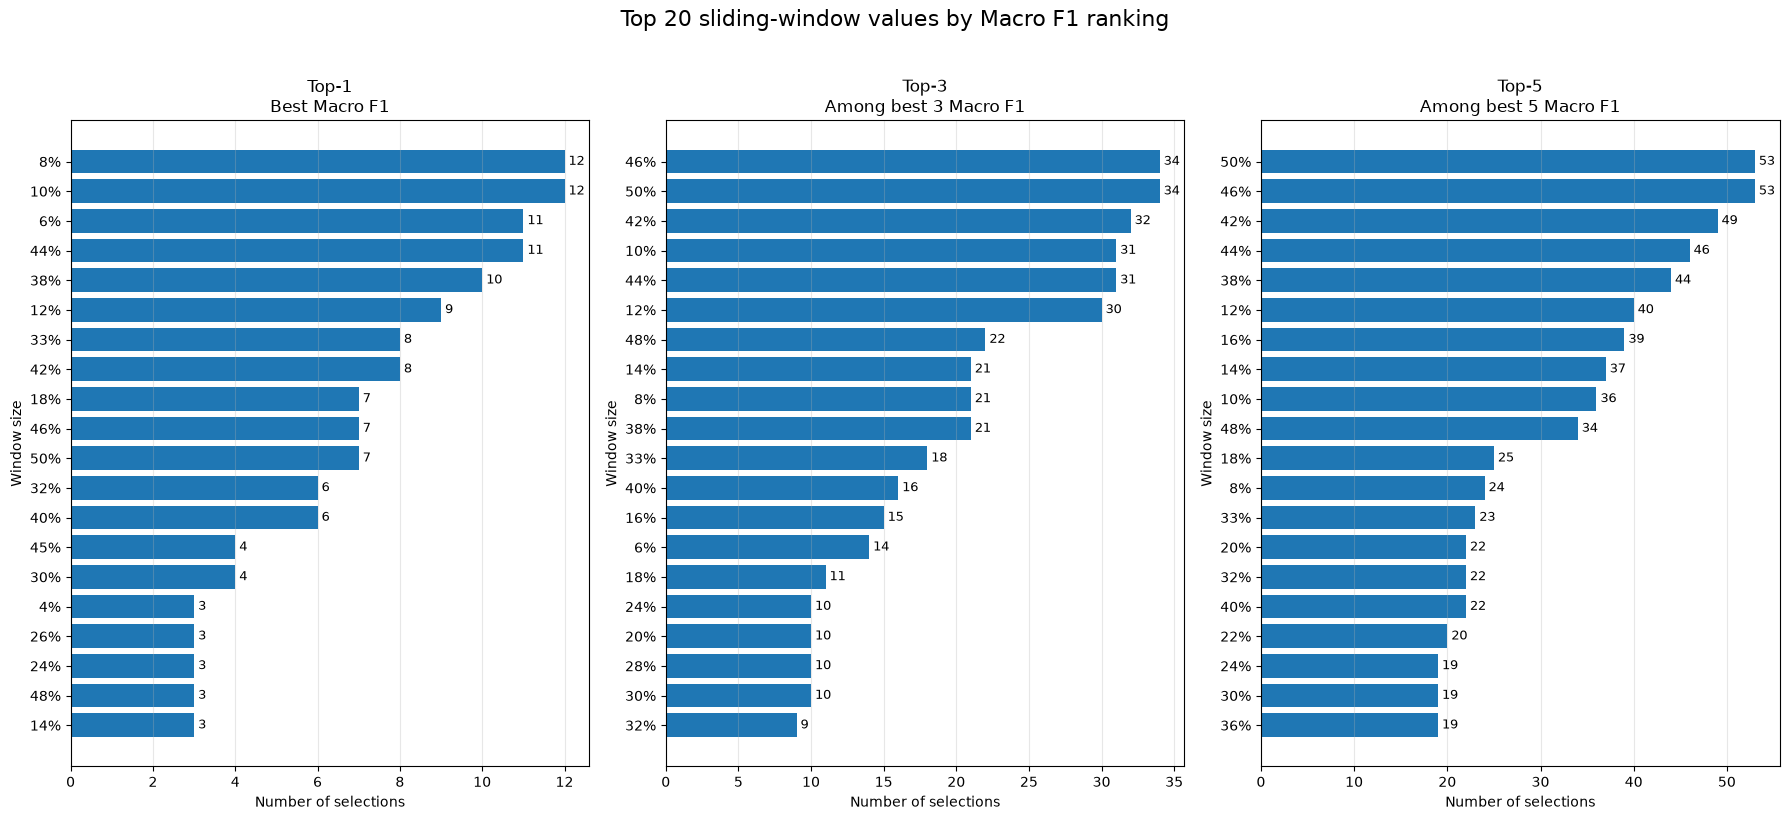

In [ ]:
# ---------------------------------------------------------------------
# Plot Top-N sliding-window values
# ---------------------------------------------------------------------

TOP_WINDOW_DIR = PLOTS_ROOT / "top_window_values"
TOP_WINDOW_DIR.mkdir(parents=True, exist_ok=True)

plot_specs = [
    {
        "counts": top1_counts,
        "title": "Top-1",
        "subtitle": "Best Macro F1",
    },
    {
        "counts": top3_counts,
        "title": "Top-3",
        "subtitle": "Among best 3 Macro F1",
    },
    {
        "counts": top5_counts,
        "title": "Top-5",
        "subtitle": "Among best 5 Macro F1",
    },
]


def plot_top_windows(top_n: int):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 8),
        facecolor="white",
    )

    for ax, spec in zip(axes, plot_specs):

        counts_df = (
            spec["counts"]
            .head(top_n)
            .copy()
            .sort_values("count", ascending=True)
        )

        ax.barh(
            counts_df["window_label"],
            counts_df["count"],
        )

        ax.set_title(
            f'{spec["title"]}\n{spec["subtitle"]}',
            fontsize=12,
        )

        ax.set_xlabel("Number of selections")
        ax.set_ylabel("Window size")
        ax.grid(axis="x", alpha=0.3)

        for i, value in enumerate(counts_df["count"]):
            ax.text(
                value,
                i,
                f" {value}",
                va="center",
                fontsize=9,
            )

    fig.suptitle(
        f"Top {top_n} sliding-window values by Macro F1 ranking",
        fontsize=16,
        y=1.02,
    )

    fig.tight_layout()

    output_file = (
        TOP_WINDOW_DIR
        / f"top{top_n}_window_values_top1_top3_top5.png"
    )

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    print("Saved:", output_file)
    plt.show()




In [29]:
# ---------------------------------------------------------------------
# Good-enough region analysis
# A window is good enough if it reaches at least 95% of the best Macro F1
# within the same dataset + classifier + stride_ratio group.
# ---------------------------------------------------------------------


GOOD_ENOUGH_DIR = PLOTS_ROOT / "good_enough_region"
GOOD_ENOUGH_DIR.mkdir(parents=True, exist_ok=True)

GOOD_ENOUGH_THRESHOLD = 0.95

good_df = ok_results.copy()

good_df["window_percentage_100"] = (
    good_df["window_percentage"] * 100
).round(0).astype(int)

group_keys = ["dataset", "classifier", "stride_ratio"]

good_df["best_macro_f1_in_group"] = (
    good_df
    .groupby(group_keys)["series_macro_f1"]
    .transform("max")
)

good_df["relative_macro_f1"] = (
    good_df["series_macro_f1"] / good_df["best_macro_f1_in_group"]
)

good_df["is_good_enough"] = (
    good_df["relative_macro_f1"] >= GOOD_ENOUGH_THRESHOLD
)

good_region_summary = (
    good_df
    .groupby(["window_percentage_100"], as_index=False)
    .agg(
        good_enough_count=("is_good_enough", "sum"),
        total_count=("is_good_enough", "count"),
        good_enough_share=("is_good_enough", "mean"),
        mean_relative_macro_f1=("relative_macro_f1", "mean"),
    )
    .sort_values("good_enough_share", ascending=False)
)

good_region_summary["window_label"] = (
    good_region_summary["window_percentage_100"].astype(str) + "%"
)

good_region_file = GOOD_ENOUGH_DIR / "good_enough_region_summary.csv"
good_region_summary.to_csv(good_region_file, index=False)

print("Saved:", good_region_file)
display(good_region_summary.head(20))

Saved: plots/benchmark_10datasets_lowcost_weasel_quant/untuned/good_enough_region/good_enough_region_summary.csv


,window_percentage_100,good_enough_count,total_count,good_enough_share,mean_relative_macro_f1,window_label
42,47,6,6,1.000000,0.986591,47%
38,43,6,6,1.000000,0.990646,43%
15,19,18,18,1.000000,0.998897,19%
34,39,19,21,0.904762,0.977656,39%
19,23,13,15,0.866667,0.979381,23%
29,33,57,66,0.863636,0.979136,33%
36,41,18,21,0.857143,0.976598,41%
41,46,112,138,0.811594,0.968111,46%
40,45,17,21,0.809524,0.976370,45%
28,32,98,123,0.796748,0.963455,32%


Saved: plots/benchmark_10datasets_lowcost_weasel_quant/untuned/good_enough_region/good_enough_region_overall.png


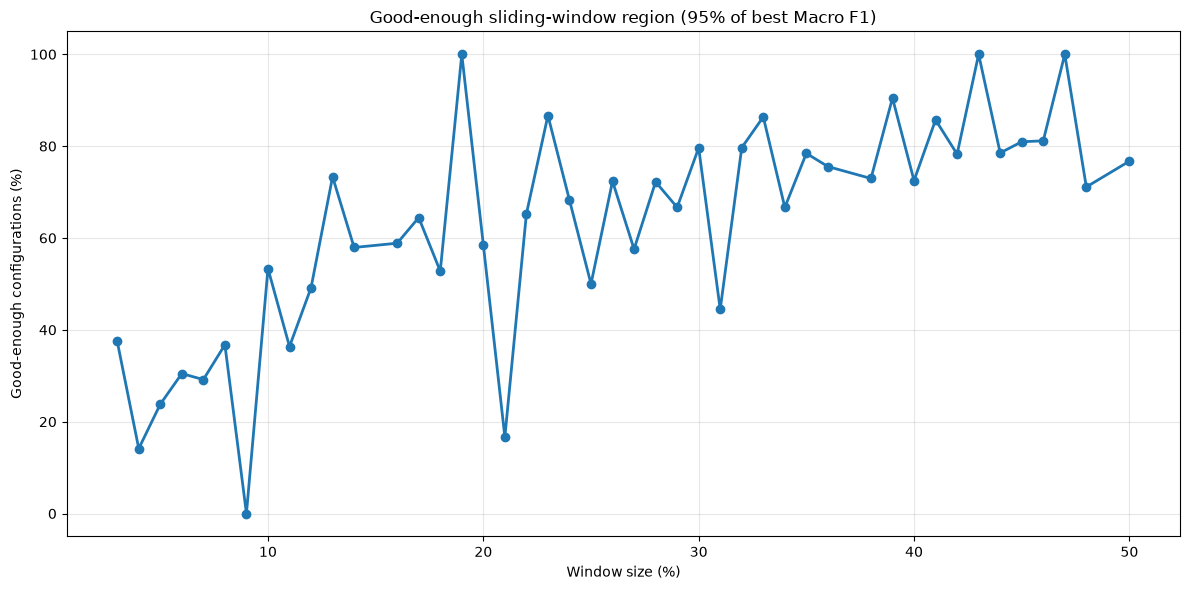

In [30]:
# ---------------------------------------------------------------------
# Plot good-enough region
# ---------------------------------------------------------------------

plot_df = good_region_summary.sort_values("window_percentage_100")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")

ax.plot(
    plot_df["window_percentage_100"],
    plot_df["good_enough_share"] * 100,
    marker="o",
    linewidth=2,
)

ax.set_title(
    f"Good-enough sliding-window region "
    f"({GOOD_ENOUGH_THRESHOLD:.0%} of best Macro F1)"
)
ax.set_xlabel("Window size (%)")
ax.set_ylabel("Good-enough configurations (%)")
ax.grid(True, alpha=0.3)

fig.tight_layout()

output_file = GOOD_ENOUGH_DIR / "good_enough_region_overall.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")

print("Saved:", output_file)
plt.show()